In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import glob

In [2]:
# Files

priority_dict = {}

In [3]:
# Import the result files

baseline_path = glob.glob('baseline/*.csv')
for file in baseline_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]

contrib_path = glob.glob('contrib/*.csv')
for file in contrib_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
discounted_path = glob.glob('discounted_contrib/*.csv')
for file in discounted_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
entropy_path = glob.glob('entropy/*.csv')
for file in entropy_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
fixed_path = glob.glob('fixed/*.csv')
for file in fixed_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
urgency_path = glob.glob('urgency/*.csv')
for file in urgency_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]
    
windowed_path = glob.glob('windowed_contrib/*.csv')
for file in windowed_path:
    filename = file.split('.')[0].split('/')[1]
    priority_dict[filename[:-7]] = pd.read_csv(file)[:-1]

In [4]:
# Columns we are interested in:
# Storage change and discharge; EV charge and discharge; Import and export

STORAGE_CHARGE = ['storage_{:02d}_charge'.format(i) for i in range(1, 21)]
STORAGE_CHARGE.remove('storage_04_charge')
STORAGE_CHARGE.remove('storage_14_charge')

STORAGE_DISCHARGE = ['storage_{:02d}_discharge'.format(i) for i in range(1, 21)]
STORAGE_DISCHARGE.remove('storage_04_discharge')
STORAGE_DISCHARGE.remove('storage_14_discharge')

STORAGE_DISCHARGE_EFF = ['storage_{:02d}_discharge_eff'.format(i) for i in range(1, 21)]
STORAGE_DISCHARGE_EFF.remove('storage_04_discharge_eff')
STORAGE_DISCHARGE_EFF.remove('storage_14_discharge_eff')

EV_CHARGE = ['ev_{:02d}_charge'.format(i) for i in range(1, 21)]
EV_CHARGE.remove('ev_04_charge')
EV_CHARGE.remove('ev_14_charge')

EV_DISCHARGE = ['ev_{:02d}_discharge'.format(i) for i in range(1, 21)]
EV_DISCHARGE.remove('ev_04_discharge')
EV_DISCHARGE.remove('ev_14_discharge')

EV_DISCHARGE_EFF = ['ev_{:02d}_discharge_eff'.format(i) for i in range(1, 21)]
EV_DISCHARGE_EFF.remove('ev_04_discharge_eff')
EV_DISCHARGE_EFF.remove('ev_14_discharge_eff')

COLUMNS_GRID = ['imports', 'exports', 'import_cost']

In [5]:
# Create a DF with sums

SEASONS = ['spring', 'summer', 'autumn', 'winter']
PRIORITY_TYPE = ['baseline', 'contrib', 'windowed_contrib', 'entropy', 'fixed', 'urgency']

COLS = ['storCharge', 'storDischarge', 'storDischargeEff', 'evCharge', 'evDischarge', 'evDischargeEff', 'imports', 'exports', 'importCost', 'exportCost']

MODE = ['training', 'testing']

RESULTS = {}

for mode in MODE:
    for season in SEASONS:
        temp_df = pd.DataFrame(index=PRIORITY_TYPE, columns=COLS)
        for priority in PRIORITY_TYPE:
            inner_df_ = priority_dict[f'{priority}_{mode}_{season}']
            temp_df.loc[priority, 'storCharge'] = inner_df_[STORAGE_CHARGE].sum().sum().round(2)
            temp_df.loc[priority, 'storDischarge'] = inner_df_[STORAGE_DISCHARGE].sum().sum().round(2)
            temp_df.loc[priority, 'storDischargeEff'] = inner_df_[STORAGE_DISCHARGE_EFF].sum().sum().round(2)
            temp_df.loc[priority, 'evCharge'] = inner_df_[EV_CHARGE].sum().sum().round(2)
            temp_df.loc[priority, 'evDischarge'] = inner_df_[EV_DISCHARGE].sum().sum().round(2)
            temp_df.loc[priority, 'evDischargeEff'] = inner_df_[EV_DISCHARGE_EFF].sum().sum().round(2)
            temp_df.loc[priority, 'imports'] = inner_df_['imports'].sum()
            temp_df.loc[priority, 'exports'] = inner_df_['exports'].sum()
            temp_df.loc[priority, 'importCost'] = (inner_df_['imports'] * inner_df_['import_cost']).sum()
            temp_df.loc[priority, 'exportCost'] = (inner_df_['exports'] * 0.04).sum()
            
        RESULTS[f'{mode}_{season}'] = temp_df

In [6]:
from src.resources import Vehicle, Generator, Load, Storage, Aggregator
from src.parsers import HMParser, CotevParser

# General data
N_HOUSES = 20
N_STEPS = 24 * 366 * 4  # 14496  # 6576  # 24 * 366
# 1 year - 2020 (leap year), 4 because we are using 15 minutes intervals

# EC data for mostly cost values
data_ec = HMParser(file_path='../../../data/EC_V4.xlsx', ec_id=1)
data_ec.parse()

# EV data from the EV4EU simulator
data_ev = CotevParser(population_path=
                      '../../../data/simulation_20evs_1year_15t/population_366.csv',
                      driving_history_path=
                      '../../../data/simulation_20evs_1year_15t/ev_driving_history_366.csv',
                      assigned_segments_path=
                      '../../../data/simulation_20evs_1year_15t/assigned_segments_366.csv',
                      parse_date_start='2020',
                      parse_date_end='2020')
data_ev.parse()

temp_costs_df = pd.DataFrame({'cost_parameter_b': data_ec.generator['cost_parameter_b'][0, 0],
                              'cost_nde': data_ec.generator['cost_nde'][0],
                              'cost_cut': data_ec.load['cost_cut'][0],
                              'cost_reduce': data_ec.load['cost_reduce'][0],
                              'cost_ens': data_ec.load['cost_ens'][0],
                              'discharge_price': np.array(data_ec.storage['discharge_price'][2]),
                              'charge_price': np.array(data_ec.storage['charge_price'][0]),
                              'import_contracted_p_max': 200,
                              'export_contracted_p_max': 200,
                              'buy_price': data_ec.peers['buy_price'][0],
                              'sell_price': data_ec.peers['sell_price'][0]},
                             index=pd.date_range(start='2020-01-01', freq='H', periods=24))
# Resample to 15T and forward fill the values
temp_costs_df = temp_costs_df.resample('15T').ffill()
# print('Initial costs DataFrame:\n{}'.format(temp_costs_df))

# Now fill the remaining 3 timestamps
temp_costs_df = temp_costs_df.reindex(pd.date_range(start='2020-01-01', freq='15T', periods=96), method='ffill')

aux_date_range = pd.date_range(start='2020-01-01', freq='15T', periods=N_STEPS)
winter_start = 0
winter_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 2].max())
spring_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 3].min())
spring_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 5].max())
summer_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 6].min())
summer_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 8].max())
autumn_start = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 9].min())
autumn_end = aux_date_range.get_loc(aux_date_range[aux_date_range.month == 11].max())

# Seasonal splits
modes = [True, False]
data = {}

for mode in MODE:
    for season in SEASONS:
        SEASON_START = 0
        SEASON_END = 0
        
        if mode == 'training':
            if season == 'winter':
                N_STEPS = winter_end - winter_start - 1344
                SEASON_START = winter_start
                SEASON_END = winter_end - 1344
            elif season == 'spring':
                N_STEPS = spring_end - spring_start - 1344
                SEASON_START = spring_start
                SEASON_END = spring_end - 1344
            elif season == 'summer':
                N_STEPS = summer_end - summer_start - 1344
                SEASON_START = summer_start
                SEASON_END = summer_end - 1344
            elif season == 'autumn':
                N_STEPS = autumn_end - autumn_start - 1344
                SEASON_START = autumn_start
                SEASON_END = autumn_end - 1344
        else:
            if season == 'winter':
                N_STEPS = 1344
                SEASON_START = winter_end - 1344
                SEASON_END = winter_end
            elif season == 'spring':
                N_STEPS = 1344
                SEASON_START = spring_end - 1344
                SEASON_END = spring_end
            elif season == 'summer':
                N_STEPS = 1344
                SEASON_START = summer_end - 1344
                SEASON_END = summer_end
            elif season == 'autumn':
                N_STEPS = 1344
                SEASON_START = autumn_end - 1344
                SEASON_END = autumn_end

        # Create the generator and load lists to add on to
        generators = []
        loads = []
        used_idx = []
        
        for i in range(1, 21):
            temp_data = pd.read_csv('../../../data/housedata/W/H{}_W.csv'.format(i))
        
            # Fill the generator and load missing data with zeros
            temp_data = temp_data.fillna(0)
        
            # Resample to 1H intervals
            temp_data['date'] = pd.to_datetime(temp_data['date'])
            temp_data = temp_data.set_index('date', drop=True)
            temp_data = temp_data.resample('15T').mean()
        
            # Convert to kWh
            temp_data[' Production(kW)'] = temp_data[' Production(W)'] / 1000
            temp_data[' Consumption(kW)'] = temp_data[' Consumption(W)'] / 1000
        
            # Check if there are enough data points
            if temp_data.shape[0] < 366 * 96:
                print(f'Not enough data for house {i}, skipping...')
                continue
        
            # Create the generator
            generators.append(Generator(name='ren_generator_{:02d}'.format(i),
                                        value=np.zeros(N_STEPS),
                                        lower_bound=np.zeros(N_STEPS),
                                        upper_bound=temp_data[' Production(kW)'][SEASON_START:SEASON_END],
                                        cost=np.tile(temp_costs_df['cost_parameter_b'], (int(N_STEPS / 95)))[:-1],
                                        cost_nde=np.tile(temp_costs_df['cost_nde'], (int(N_STEPS / 95)))[:-1],
                                        is_renewable=True))
        
            # Create the load
            loads.append(Load(name='load_{:02d}'.format(i),
                              value=temp_data[' Consumption(kW)'][SEASON_START:SEASON_END],
                              lower_bound=np.zeros(N_STEPS),
                              upper_bound=temp_data[' Consumption(kW)'][SEASON_START:SEASON_END],
                              cost=np.ones(N_STEPS),
                              cost_cut=np.tile(temp_costs_df['cost_cut'], (int(N_STEPS / 95)))[:-1],
                              cost_reduce=np.tile(temp_costs_df['cost_reduce'], (int(N_STEPS / 95)))[:-1],
                              cost_ens=np.tile(temp_costs_df['cost_ens'], (int(N_STEPS / 95)))[:-1]))
        
            used_idx.append(i - 1)  # Store the index of the house used
        
        # Create the storages
        storages = []
        for i in used_idx:
            storages.append(Storage(name='storage_{:02d}'.format(i + 1),
                                    value=np.tile(8.0, N_STEPS),
                                    lower_bound=np.tile(2.0, N_STEPS),
                                    upper_bound=np.tile(10.0, N_STEPS),
                                    cost=np.zeros(N_STEPS),
                                    cost_discharge=np.tile(temp_costs_df['discharge_price'], (int(N_STEPS / 95)))[:-1],
                                    cost_charge=np.tile(temp_costs_df['charge_price'], (int(N_STEPS / 95)))[:-1],
                                    capacity_max=10.0,
                                    capacity_min=2.0,  # 0.2 * capacity_max
                                    initial_charge=8.0,
                                    discharge_efficiency=0.95,
                                    discharge_max=np.tile(3.3, N_STEPS),
                                    charge_efficiency=0.95,
                                    charge_max=np.tile(3.3, N_STEPS),
                                    capital_cost=np.array([0.05250, 0.10500, 0.01575])))
        
        # EVs are already in the data_ev.resources, but we'll trim the excess data
        evs = []
        for i in used_idx:
            temp_res = data_ev.resources[i]
            evs.append(Vehicle(name='ev_{:02d}'.format(i + 1),
                               value=temp_res.value[SEASON_START:SEASON_END],
                               lower_bound=temp_res.lower_bound[SEASON_START:SEASON_END],
                               upper_bound=temp_res.upper_bound[SEASON_START:SEASON_END],
                               cost=temp_res.cost[SEASON_START:SEASON_END],
                               cost_discharge=temp_res.cost_discharge[SEASON_START:SEASON_END],
                               cost_charge=temp_res.cost_charge[SEASON_START:SEASON_END],
                               capacity_max=temp_res.capacity_max,
                               initial_charge=temp_res.initial_charge,
                               min_charge=temp_res.min_charge,
                               discharge_efficiency=temp_res.discharge_efficiency,
                               charge_efficiency=temp_res.charge_efficiency,
                               schedule_connected=temp_res.schedule_connected[SEASON_START:SEASON_END],
                               schedule_discharge=temp_res.schedule_discharge[SEASON_START:SEASON_END],
                               schedule_charge=temp_res.schedule_charge[SEASON_START:SEASON_END],
                               schedule_requirement_soc=temp_res.schedule_requirement_soc[SEASON_START:SEASON_END],
                               schedule_arrival_soc=temp_res.schedule_arrival_soc[SEASON_START:SEASON_END]))
        
        # Create the aggregator
        aggregator = Aggregator(name='aggregator',
                                value=np.zeros(N_STEPS),
                                lower_bound=np.zeros(N_STEPS),
                                upper_bound=np.tile(temp_costs_df['import_contracted_p_max'], (int(N_STEPS / 95)))[:-1],
                                cost=np.tile(data_ec.peers['buy_price'], (int(N_STEPS / 95)))[:-1],
                                imports=np.zeros(N_STEPS),
                                exports=np.zeros(N_STEPS),
                                import_cost=np.tile(temp_costs_df['buy_price'] * 2, (int(N_STEPS / 95)))[:-1],
                                export_cost=np.tile(temp_costs_df['sell_price'], (int(N_STEPS / 95)))[:-1],
                                import_max=np.tile(temp_costs_df['import_contracted_p_max'], (int(N_STEPS / 95)))[:-1],
                                export_max=np.tile(temp_costs_df['export_contracted_p_max'], (int(N_STEPS / 95)))[:-1])
        
        temp_data = {'gens': generators, 'loads': loads, 'stors': storages, 'evs': evs, 'aggregator': aggregator}
        data[f'{mode}_{season}'] = temp_data

2026-05-13 22:23:57,092	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!
2026-05-13 22:23:58,142	WARNING deprecation.py:50 -- DeprecationWarning: `build_tf_policy` has been deprecated. This will raise an error in the future!
2026-05-13 22:23:58,145	WARNING deprecation.py:50 -- DeprecationWarning: `build_policy_class` has been deprecated. This will raise an error in the future!


Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...
Not enough data for house 4, skipping...
Not enough data for house 14, skipping...


In [7]:
# Calculate SS and SC

RESULTS_SS_SC = {}
for mode in MODE:
    for season in SEASONS:
        temp_data = pd.DataFrame(index=PRIORITY_TYPE, columns=['ss', 'sc'])
        total_loads_ = np.array([i.value.sum() for i in data[f'{mode}_{season}']['loads']]).sum()
        total_gens_ = np.array([i.value.sum() for i in data[f'{mode}_{season}']['gens']]).sum()
        for priority in PRIORITY_TYPE:
            # SS = (total_consumption - imports) / total_consumption
            # total_consumption = loads + storCharge + evCharge
            total_consumption_ = total_loads_ + RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'storCharge'] + RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'evCharge']
            temp_data.loc[priority, 'ss'] = (total_consumption_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'imports']) / total_consumption_
            
            total_production_ = total_gens_ + RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'storDischargeEff'] + RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'evDischargeEff']
            temp_data.loc[priority, 'sc'] = (total_production_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'exports']) / total_production_
            
        RESULTS_SS_SC[f'{mode}_{season}'] = temp_data

/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_3557/3859865662.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  temp_data.loc[priority, 'sc'] = (total_production_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'exports']) / total_production_
/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_3557/3859865662.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  temp_data.loc[priority, 'sc'] = (total_production_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'exports']) / total_production_
/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_3557/3859865662.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  temp_data.loc[priority, 'sc'] = (total_production_ - RESULTS[f'{mode}_{season}'].loc[f'{priority}', 'exports']) / total_production_
/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_3557/3859865662.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  temp_data.loc[priority, 'sc'

In [8]:
RESULTS_SS_SC['testing_autumn'].iloc[1:].sort_values(by='sc', ascending=False)

,ss,sc
contrib,0.132285,1.0
entropy,0.132237,1.0
fixed,0.132445,1.0
windowed_contrib,0.139292,0.999919
urgency,0.137116,0.999545


In [98]:
RESULTS_SS_SC['testing_winter'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ss,5.0,0.155792,0.002288,0.152496,0.155236,0.155289,0.157853,0.158087
sc,5.0,0.981819,0.005743,0.977138,0.977998,0.979611,0.983101,0.991247


In [18]:
RESULTS['training_spring'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,10467.210000,375.684671,10066.090000,10082.970000,10622.920000,10652.530000,10911.540000
storDischarge,5.0,9528.348000,336.393208,9168.460000,9182.560000,9671.810000,9697.810000,9921.100000
storDischargeEff,5.0,10029.840000,354.095026,9651.010000,9665.860000,10180.850000,10208.220000,10443.260000
evCharge,5.0,21030.382000,172.852971,20804.030000,20887.540000,21113.220000,21171.160000,21175.960000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,76323.649599,163.698194,76102.158168,76219.643033,76349.486564,76443.927964,76503.032265
exports,5.0,222.536134,62.703857,181.375400,185.119900,203.997600,209.557200,332.630567
importCost,5.0,13261.432342,170.162339,13031.247445,13144.705213,13307.291601,13382.032804,13441.884647
exportCost,5.0,8.901445,2.508154,7.255016,7.404796,8.159904,8.382288,13.305223


In [27]:
RESULTS['training_spring'].sort_values(by='exportCost', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,55960.258,1828.386533,9459.377436,73.135461
windowed_contrib,10622.92,9671.81,10180.85,20804.03,0.0,0.0,76219.643033,332.630567,13031.247445,13.305223
urgency,10911.54,9921.1,10443.26,21171.16,0.0,0.0,76503.032265,209.5572,13307.291601,8.382288
contrib,10082.97,9182.56,9665.86,21113.22,0.0,0.0,76349.486564,203.9976,13441.884647,8.159904
fixed,10066.09,9168.46,9651.01,20887.54,0.0,0.0,76102.158168,185.1199,13144.705213,7.404796
entropy,10652.53,9697.81,10208.22,21175.96,0.0,0.0,76443.927964,181.3754,13382.032804,7.255016


In [12]:
# Create the sum of energy required for the trips

training_spring_ev = np.array([ev.schedule_requirement_soc.sum() for ev in data['training_spring']['evs']]).sum()
training_spring_ev

20439.394879999993

In [13]:
sum([i.value.sum() for i in data['training_spring']['loads']])

71492.03993333333

In [15]:
RESULTS['training_summer']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,53948.834867,1788.1068,9193.662221,71.524272
contrib,10469.65,9531.72,10033.39,21038.36,0.0,0.0,74278.203864,141.187201,13041.81619,5.647488
discounted_contrib,10054.2,9158.47,9640.49,21048.1,0.0,0.0,74340.584868,236.0218,13150.870685,9.440872
entropy,10852.85,9874.7,10394.42,21018.35,0.0,0.0,74316.790236,159.561867,12923.785231,6.382475
fixed,11010.5,10014.4,10541.48,21046.14,0.0,0.0,74441.679867,238.7141,13117.312927,9.548564
urgency,10700.51,9737.53,10250.03,21048.13,0.0,0.0,74381.516763,209.6767,13188.008962,8.387068


In [16]:
# Create the sum of energy required for the trips

training_summer_ev = np.array([ev.schedule_requirement_soc.sum() for ev in evs]).sum()
training_summer_ev

3657.3004399999986

In [41]:
RESULTS['training_summer'].sort_values(by='exports', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,53948.834867,1788.1068,9193.662221,71.524272
windowed_contrib,10244.7,9334.47,9825.75,21048.1,0.0,0.0,74381.626832,262.560968,13143.252159,10.502439
fixed,11010.5,10014.4,10541.48,21046.14,0.0,0.0,74441.679867,238.7141,13117.312927,9.548564
urgency,10700.51,9737.53,10250.03,21048.13,0.0,0.0,74381.516763,209.6767,13188.008962,8.387068
entropy,10852.85,9874.7,10394.42,21018.35,0.0,0.0,74316.790236,159.561867,12923.785231,6.382475
contrib,10469.65,9531.72,10033.39,21038.36,0.0,0.0,74278.203864,141.187201,13041.81619,5.647488


In [37]:
RESULTS['training_summer'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,10655.642000,304.259217,10244.700000,10469.650000,10700.510000,10852.850000,11010.500000
storDischarge,5.0,9698.564000,270.506922,9334.470000,9531.720000,9737.530000,9874.700000,10014.400000
storDischargeEff,5.0,10209.014000,284.748319,9825.750000,10033.390000,10250.030000,10394.420000,10541.480000
evCharge,5.0,21039.816000,12.655526,21018.350000,21038.360000,21046.140000,21048.100000,21048.130000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,74359.963513,63.560948,74278.203864,74316.790236,74381.516763,74381.626832,74441.679867
exports,5.0,202.340167,51.412792,141.187201,159.561867,209.676700,238.714100,262.560968
importCost,5.0,13082.835094,103.537306,12923.785231,13041.816190,13117.312927,13143.252159,13188.008962
exportCost,5.0,8.093607,2.056512,5.647488,6.382475,8.387068,9.548564,10.502439


In [18]:
RESULTS['training_autumn']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,58953.7534,1941.769867,10107.201557,77.670795
contrib,10246.99,9333.42,9824.65,20926.6,0.0,0.0,79039.181331,187.026101,13694.368301,7.481044
discounted_contrib,10177.31,9260.75,9748.15,20250.57,0.0,0.0,78356.367565,177.243133,13633.023919,7.089725
entropy,10372.49,9440.13,9936.98,20733.8,0.0,0.0,78863.856835,185.7058,13831.940845,7.428232
fixed,10487.24,9541.93,10044.14,20950.16,0.0,0.0,79072.200032,164.7465,13876.019629,6.58986
urgency,10631.46,9682.36,10191.96,17512.76,0.0,0.0,75924.313266,450.470533,13308.365781,18.018821


In [19]:
# Create the sum of energy required for the trips

training_autumn_ev = np.array([ev.schedule_requirement_soc.sum() for ev in evs]).sum()
training_autumn_ev

3657.3004399999986

In [50]:
RESULTS['training_autumn'].sort_values(by='exports', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,58953.7534,1941.769867,10107.201557,77.670795
urgency,10631.46,9682.36,10191.96,17512.76,0.0,0.0,75924.313266,450.470533,13308.365781,18.018821
windowed_contrib,11684.09,10611.98,11170.51,20958.61,0.0,0.0,79364.667862,321.968333,14053.048604,12.878733
contrib,10246.99,9333.42,9824.65,20926.6,0.0,0.0,79039.181331,187.026101,13694.368301,7.481044
entropy,10372.49,9440.13,9936.98,20733.8,0.0,0.0,78863.856835,185.7058,13831.940845,7.428232
fixed,10487.24,9541.93,10044.14,20950.16,0.0,0.0,79072.200032,164.7465,13876.019629,6.58986


In [45]:
RESULTS['training_autumn'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,10684.454000,576.556621,10246.990000,10372.490000,10487.240000,10631.460000,11684.090000
storDischarge,5.0,9721.964000,513.932399,9333.420000,9440.130000,9541.930000,9682.360000,10611.980000
storDischargeEff,5.0,10233.648000,540.983559,9824.650000,9936.980000,10044.140000,10191.960000,11170.510000
evCharge,5.0,20216.386000,1514.185876,17512.760000,20733.800000,20926.600000,20950.160000,20958.610000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,78452.843865,1424.887306,75924.313266,78863.856835,79039.181331,79072.200032,79364.667862
exports,5.0,261.983453,122.492322,164.746500,185.705800,187.026101,321.968333,450.470533
importCost,5.0,13752.748632,279.522628,13308.365781,13694.368301,13831.940845,13876.019629,14053.048604
exportCost,5.0,10.479338,4.899693,6.589860,7.428232,7.481044,12.878733,18.018821


In [22]:
RESULTS['training_winter']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,37341.892733,521.378733,6441.591572,20.855149
contrib,6002.6,5497.17,5786.5,12614.68,0.0,0.0,50017.998867,77.373167,8878.71346,3.094927
discounted_contrib,5684.73,5217.03,5491.62,12614.66,0.0,0.0,49978.363566,75.498367,8853.097665,3.019935
entropy,6144.27,5612.43,5907.82,12509.07,0.0,0.0,49953.018198,91.5933,8931.92822,3.663732
fixed,5707.65,5225.4,5500.42,12569.61,0.0,0.0,49942.805099,70.4354,8869.893822,2.817416
urgency,5870.65,5377.98,5661.03,12614.68,0.0,0.0,49986.112137,58.245733,8890.627549,2.329829


In [23]:
# Create the sum of energy required for the trips

training_winter_ev = np.array([ev.schedule_requirement_soc.sum() for ev in evs]).sum()
training_winter_ev

3657.3004399999986

In [61]:
RESULTS['training_winter'].sort_values(by='exports', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,37341.892733,521.378733,6441.591572,20.855149
entropy,6144.27,5612.43,5907.82,12509.07,0.0,0.0,49953.018198,91.5933,8931.92822,3.663732
contrib,6002.6,5497.17,5786.5,12614.68,0.0,0.0,50017.998867,77.373167,8878.71346,3.094927
fixed,5707.65,5225.4,5500.42,12569.61,0.0,0.0,49942.805099,70.4354,8869.893822,2.817416
urgency,5870.65,5377.98,5661.03,12614.68,0.0,0.0,49986.112137,58.245733,8890.627549,2.329829
windowed_contrib,5992.21,5482.15,5770.68,12596.15,0.0,0.0,49958.989801,32.2652,8803.42526,1.290608


In [62]:
RESULTS['training_winter'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,5943.476000,163.635578,5707.650000,5870.650000,5992.210000,6002.600000,6144.270000
storDischarge,5.0,5439.026000,145.492296,5225.400000,5377.980000,5482.150000,5497.170000,5612.430000
storDischargeEff,5.0,5725.290000,153.150238,5500.420000,5661.030000,5770.680000,5786.500000,5907.820000
evCharge,5.0,12580.838000,44.163710,12509.070000,12569.610000,12596.150000,12614.680000,12614.680000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,49971.784820,30.400382,49942.805099,49953.018198,49958.989801,49986.112137,50017.998867
exports,5.0,65.982560,22.372989,32.265200,58.245733,70.435400,77.373167,91.593300
importCost,5.0,8874.917662,46.496814,8803.425260,8869.893822,8878.713460,8890.627549,8931.928220
exportCost,5.0,2.639302,0.894920,1.290608,2.329829,2.817416,3.094927,3.663732


In [12]:
RESULTS['testing_spring'].transpose().round(2)#.to_latex()

,baseline,contrib,windowed_contrib,entropy,fixed,urgency
storCharge,0.0,1956.16,2006.53,2023.5,1881.25,2056.11
storDischarge,0.0,1849.76,1895.69,1911.24,1781.96,1929.16
storDischargeEff,0.0,1947.11,1995.46,2011.84,1875.74,2030.69
evCharge,0.0,3976.76,3888.69,3976.44,3904.21,3962.78
evDischarge,0.0,0.0,0.0,0.0,0.0,0.0
evDischargeEff,0.0,0.0,0.0,0.0,0.0,0.0
imports,7886.119,11404.519467,11342.180566,11368.069466,11267.6364,11400.199935
exports,707.859467,143.092933,164.394733,101.119333,85.869666,132.2052
importCost,1300.694281,1968.200316,1893.338592,1948.092699,1901.95814,1938.133224
exportCost,28.314379,5.723717,6.575789,4.044773,3.434787,5.288208


In [9]:
RESULTS['testing_spring'].iloc[1:].sort_values(by='imports', ascending=True)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
fixed,1881.25,1781.96,1875.74,3904.21,0.0,0.0,11267.6364,85.869666,1901.95814,3.434787
windowed_contrib,2006.53,1895.69,1995.46,3888.69,0.0,0.0,11342.180566,164.394733,1893.338592,6.575789
entropy,2023.5,1911.24,2011.84,3976.44,0.0,0.0,11368.069466,101.119333,1948.092699,4.044773
urgency,2056.11,1929.16,2030.69,3962.78,0.0,0.0,11400.199935,132.2052,1938.133224,5.288208
contrib,1956.16,1849.76,1947.11,3976.76,0.0,0.0,11404.519467,143.092933,1968.200316,5.723717


In [73]:
RESULTS['testing_spring'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1984.710000,68.186895,1881.250000,1956.160000,2006.530000,2023.500000,2056.110000
storDischarge,5.0,1873.562000,59.071735,1781.960000,1849.760000,1895.690000,1911.240000,1929.160000
storDischargeEff,5.0,1972.168000,62.184146,1875.740000,1947.110000,1995.460000,2011.840000,2030.690000
evCharge,5.0,3941.776000,42.118787,3888.690000,3904.210000,3962.780000,3976.440000,3976.760000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,11356.521167,55.792449,11267.636400,11342.180566,11368.069466,11400.199935,11404.519467
exports,5.0,125.336373,31.749479,85.869666,101.119333,132.205200,143.092933,164.394733
importCost,5.0,1929.944594,31.556095,1893.338592,1901.958140,1938.133224,1948.092699,1968.200316
exportCost,5.0,5.013455,1.269979,3.434787,4.044773,5.288208,5.723717,6.575789


In [29]:
RESULTS['testing_summer']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,9070.896333,376.159,1529.67634,15.04636
contrib,1968.27,1858.97,1956.81,4036.89,0.0,0.0,12858.977466,18.049633,2226.757162,0.721985
discounted_contrib,1887.43,1787.76,1881.85,4039.26,0.0,0.0,12910.897965,77.233333,2254.049215,3.089333
entropy,2030.5,1912.23,2012.87,4004.26,0.0,0.0,12838.3446,21.081366,2207.194529,0.843255
fixed,2027.54,1906.69,2007.04,4033.21,0.0,0.0,12885.397933,36.5913,2240.53879,1.463652
urgency,1999.3,1884.17,1983.34,4039.52,0.0,0.0,12889.003533,39.6188,2254.187913,1.584752


In [83]:
RESULTS['testing_summer'].sort_values(by='exports', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,9070.896333,376.159,1529.67634,15.04636
windowed_contrib,1883.23,1788.47,1882.6,4039.26,0.0,0.0,12874.958399,46.205567,2240.564745,1.848223
urgency,1999.3,1884.17,1983.34,4039.52,0.0,0.0,12889.003533,39.6188,2254.187913,1.584752
fixed,2027.54,1906.69,2007.04,4033.21,0.0,0.0,12885.397933,36.5913,2240.53879,1.463652
entropy,2030.5,1912.23,2012.87,4004.26,0.0,0.0,12838.3446,21.081366,2207.194529,0.843255
contrib,1968.27,1858.97,1956.81,4036.89,0.0,0.0,12858.977466,18.049633,2226.757162,0.721985


In [84]:
RESULTS['testing_summer'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1981.768000,60.558212,1883.230000,1968.270000,1999.300000,2027.540000,2030.500000
storDischarge,5.0,1870.106000,50.247048,1788.470000,1858.970000,1884.170000,1906.690000,1912.230000
storDischargeEff,5.0,1968.532000,52.890725,1882.600000,1956.810000,1983.340000,2007.040000,2012.870000
evCharge,5.0,4030.628000,14.956018,4004.260000,4033.210000,4036.890000,4039.260000,4039.520000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,12869.336386,20.881661,12838.344600,12858.977466,12874.958399,12885.397933,12889.003533
exports,5.0,32.309333,12.188879,18.049633,21.081366,36.591300,39.618800,46.205567
importCost,5.0,2233.848628,17.778364,2207.194529,2226.757162,2240.538790,2240.564745,2254.187913
exportCost,5.0,1.292373,0.487555,0.721985,0.843255,1.463652,1.584752,1.848223


In [32]:
RESULTS['testing_autumn']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,13828.428933,26.6368,2412.204144,1.065472
contrib,1807.9,1715.29,1805.57,4002.17,0.0,0.0,17896.569533,0.0,3134.498848,0.0
discounted_contrib,1869.7,1762.84,1855.62,3972.84,0.0,0.0,17881.491532,0.0,3139.740388,0.0
entropy,1801.06,1703.04,1792.68,3923.95,0.0,0.0,17823.754434,0.0,3155.267063,0.0
fixed,1826.69,1724.35,1815.11,4026.84,0.0,0.0,17930.971033,0.0,3173.981587,0.0
urgency,1840.63,1747.64,1839.62,3472.51,0.0,0.0,17368.129566,0.836933,3074.41818,0.033477


In [94]:
RESULTS['testing_autumn'].sort_values(by='exports', ascending=False)

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,13828.428933,26.6368,2412.204144,1.065472
urgency,1840.63,1747.64,1839.62,3472.51,0.0,0.0,17368.129566,0.836933,3074.41818,0.033477
windowed_contrib,2024.12,1894.49,1994.2,4033.79,0.0,0.0,17965.369632,0.1606,3201.184733,0.006424
contrib,1807.9,1715.29,1805.57,4002.17,0.0,0.0,17896.569533,0.0,3134.498848,0.0
entropy,1801.06,1703.04,1792.68,3923.95,0.0,0.0,17823.754434,0.0,3155.267063,0.0
fixed,1826.69,1724.35,1815.11,4026.84,0.0,0.0,17930.971033,0.0,3173.981587,0.0


In [95]:
RESULTS['testing_autumn'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1860.080000,93.016704,1801.060000,1807.900000,1826.690000,1840.630000,2024.120000
storDischarge,5.0,1756.962000,78.594737,1703.040000,1715.290000,1724.350000,1747.640000,1894.490000
storDischargeEff,5.0,1849.436000,82.729549,1792.680000,1805.570000,1815.110000,1839.620000,1994.200000
evCharge,5.0,3891.852000,238.440879,3472.510000,3923.950000,4002.170000,4026.840000,4033.790000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,17796.958840,245.385566,17368.129566,17823.754434,17896.569533,17930.971033,17965.369632
exports,5.0,0.199507,0.363055,0.000000,0.000000,0.000000,0.160600,0.836933
importCost,5.0,3147.870082,47.835525,3074.418180,3134.498848,3155.267063,3173.981587,3201.184733
exportCost,5.0,0.007980,0.014522,0.000000,0.000000,0.000000,0.006424,0.033477


In [35]:
RESULTS['testing_winter']

,storCharge,storDischarge,storDischargeEff,evCharge,evDischarge,evDischargeEff,imports,exports,importCost,exportCost
baseline,0.0,0.0,0.0,0.0,0.0,0.0,13850.907667,152.385533,2365.353122,6.095421
contrib,1832.97,1731.1,1822.21,4015.0,0.0,0.0,17852.537067,37.153133,3136.669791,1.486125
discounted_contrib,1768.23,1679.92,1768.34,4015.0,0.0,0.0,17834.939634,33.1163,3133.573817,1.324652
entropy,1927.05,1805.64,1900.67,3971.32,0.0,0.0,17834.711766,43.453934,3151.756182,1.738157
fixed,1749.21,1654.01,1741.06,3965.36,0.0,0.0,17797.3857,38.306967,3136.435293,1.532279
urgency,1824.47,1724.43,1815.19,4015.0,0.0,0.0,17844.231632,30.6758,3143.862709,1.227032


In [36]:
TEMP_KEY = 'importCost'
RESULTS['testing_winter'].sort_values(by=TEMP_KEY, ascending=True)[TEMP_KEY]

baseline            2365.353122
windowed_contrib    3110.453619
fixed               3136.435293
contrib             3136.669791
urgency             3143.862709
entropy             3151.756182
Name: importCost, dtype: object

In [11]:
RESULTS['testing_autumn'].iloc[1:].astype(float).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1860.080000,93.016704,1801.060000,1807.900000,1826.690000,1840.630000,2024.120000
storDischarge,5.0,1756.962000,78.594737,1703.040000,1715.290000,1724.350000,1747.640000,1894.490000
storDischargeEff,5.0,1849.436000,82.729549,1792.680000,1805.570000,1815.110000,1839.620000,1994.200000
evCharge,5.0,3891.852000,238.440879,3472.510000,3923.950000,4002.170000,4026.840000,4033.790000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,17796.958840,245.385566,17368.129566,17823.754434,17896.569533,17930.971033,17965.369632
exports,5.0,0.199507,0.363055,0.000000,0.000000,0.000000,0.160600,0.836933
importCost,5.0,3147.870082,47.835525,3074.418180,3134.498848,3155.267063,3173.981587,3201.184733
exportCost,5.0,0.007980,0.014522,0.000000,0.000000,0.000000,0.006424,0.033477


In [38]:
# Priority orders - Training Spring

priority_dict['contrib_training_spring']['order_history'][0]

"['ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_11' 'ev_07' 'ev_06' 'ev_05'\n 'ev_16' 'ev_15' 'ev_09' 'ev_20' 'ev_18' 'ev_10' 'ev_17' 'ev_01' 'ev_13'\n 'storage_20' 'storage_10' 'storage_03' 'storage_05' 'storage_06'\n 'storage_07' 'storage_08' 'storage_09' 'storage_11' 'storage_02'\n 'storage_12' 'storage_13' 'storage_15' 'storage_16' 'storage_17'\n 'storage_18' 'storage_19' 'storage_01' 'aggregator']"

In [22]:
# Get the order over time - Contrib

contrib_order_history = pd.DataFrame({})
contrib_order_history['order_list'] = priority_dict['contrib_testing_autumn']['order_history']
contrib_order_history.index = priority_dict['contrib_testing_autumn']['order_history'].index

contrib_order_history['order_str'] = contrib_order_history['order_list'].str.replace('[', '')
contrib_order_history['order_str'] = contrib_order_history['order_str'].str.replace(']', '')
contrib_order_history['order_str'] = contrib_order_history['order_str'].str.replace('\n', '')
#df_order_history['order_str'] = df_order_history['order_list'].apply(lambda x: ','.join(x))

# Add a column with the order encoded
unique_orders = sorted(set(contrib_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
contrib_order_history['order'] = [encoded_orders[i] for i in contrib_order_history['order_str']]
contrib_order_history.head(5)

,order_list,order_str,order
0,['ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_1...,'ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_11...,512
1,['storage_19' 'storage_11' 'storage_17' 'ev_01...,'storage_19' 'storage_11' 'storage_17' 'ev_01'...,528
2,['storage_19' 'storage_11' 'storage_12' 'stora...,'storage_19' 'storage_11' 'storage_12' 'storag...,527
3,['ev_01' 'ev_17' 'storage_19' 'ev_10' 'storage...,'ev_01' 'ev_17' 'storage_19' 'ev_10' 'storage_...,13
4,['ev_01' 'ev_17' 'ev_10' 'ev_18' 'storage_19' ...,'ev_01' 'ev_17' 'ev_10' 'ev_18' 'storage_19' '...,10


In [23]:
contrib_order_history['order'].value_counts()

order
473    72
499    45
244    31
476    29
430    28
       ..
409     1
407     1
403     1
404     1
498     1
Name: count, Length: 530, dtype: int64

In [24]:
contrib_order_history[contrib_order_history['order'] == 284].head(1)['order_str']

718    'ev_09' 'storage_20' 'storage_16' 'storage_02'...
Name: order_str, dtype: object

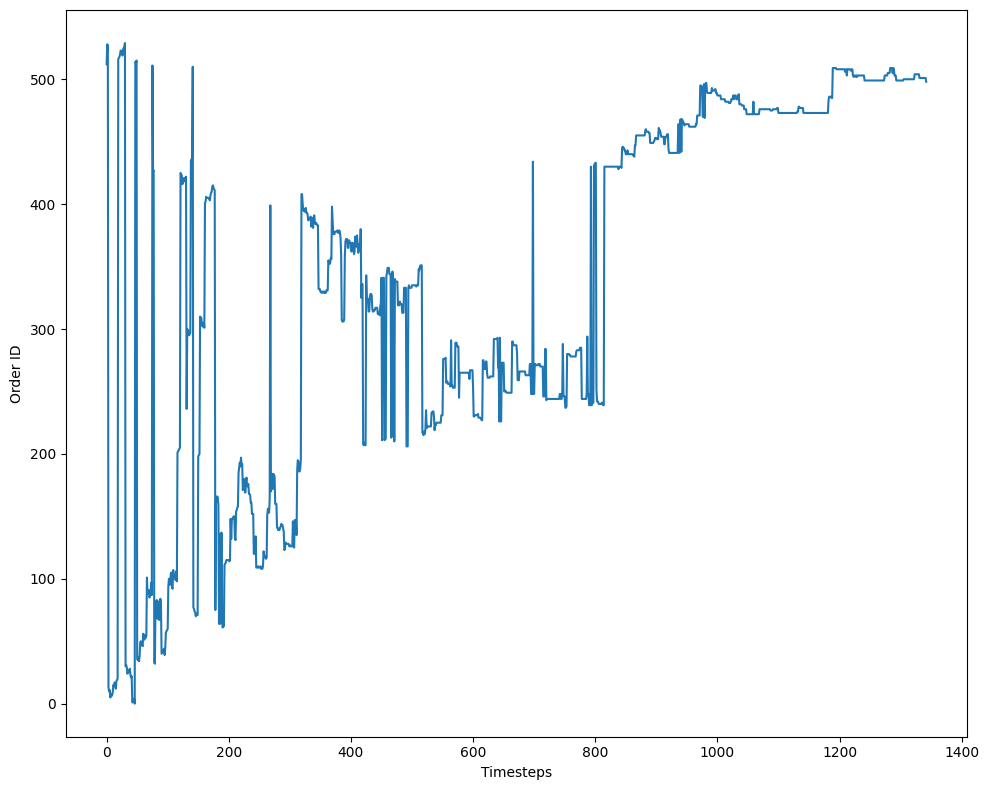

In [25]:
# Plot the contrib mechanism ordering over Autumn

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(10, 8))

contrib_order_history['order'].plot(ax=axs)

axs.set_ylabel('Order ID')
axs.set_xlabel('Timesteps')

plt.tight_layout()

plt.savefig('contrib_autumn.pdf', dpi=300, format='pdf')
plt.show()

In [26]:
# Get the order over time - Contrib

windowed_contrib_order_history = pd.DataFrame({})
windowed_contrib_order_history['order_list'] = priority_dict['windowed_contrib_testing_autumn']['order_history']
windowed_contrib_order_history.index = priority_dict['windowed_contrib_testing_autumn']['order_history'].index

windowed_contrib_order_history['order_str'] = windowed_contrib_order_history['order_list'].str.replace('[', '')
windowed_contrib_order_history['order_str'] = windowed_contrib_order_history['order_str'].str.replace(']', '')
windowed_contrib_order_history['order_str'] = windowed_contrib_order_history['order_str'].str.replace('\n', '')
#df_order_history['order_str'] = df_order_history['order_list'].apply(lambda x: ','.join(x))

# Add a column with the order encoded
unique_orders = sorted(set(windowed_contrib_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
windowed_contrib_order_history['order'] = [encoded_orders[i] for i in windowed_contrib_order_history['order_str']]
windowed_contrib_order_history.head(5)

,order_list,order_str,order
0,['ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_1...,'ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_11...,763
1,['storage_20' 'storage_15' 'storage_01' 'stora...,'storage_20' 'storage_15' 'storage_01' 'storag...,1342
2,['storage_20' 'storage_01' 'storage_15' 'stora...,'storage_20' 'storage_01' 'storage_15' 'storag...,1339
3,['storage_01' 'storage_20' 'ev_01' 'storage_07...,'storage_01' 'storage_20' 'ev_01' 'storage_07'...,888
4,['ev_01' 'storage_20' 'ev_17' 'storage_12' 'st...,'ev_01' 'storage_20' 'ev_17' 'storage_12' 'sto...,11


In [27]:
windowed_contrib_order_history['order'].value_counts()

order
763    1
245    1
180    1
182    1
181    1
      ..
34     1
68     1
32     1
33     1
692    1
Name: count, Length: 1343, dtype: int64

In [28]:
windowed_contrib_order_history

,order_list,order_str,order
0,['ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_1...,'ev_12' 'ev_02' 'ev_08' 'ev_03' 'ev_19' 'ev_11...,763
1,['storage_20' 'storage_15' 'storage_01' 'stora...,'storage_20' 'storage_15' 'storage_01' 'storag...,1342
2,['storage_20' 'storage_01' 'storage_15' 'stora...,'storage_20' 'storage_01' 'storage_15' 'storag...,1339
3,['storage_01' 'storage_20' 'ev_01' 'storage_07...,'storage_01' 'storage_20' 'ev_01' 'storage_07'...,888
4,['ev_01' 'storage_20' 'ev_17' 'storage_12' 'st...,'ev_01' 'storage_20' 'ev_17' 'storage_12' 'sto...,11
...,...,...,...
1338,['ev_09' 'ev_13' 'storage_13' 'storage_17' 'st...,'ev_09' 'ev_13' 'storage_13' 'storage_17' 'sto...,345
1339,['ev_09' 'ev_13' 'storage_18' 'storage_13' 'st...,'ev_09' 'ev_13' 'storage_18' 'storage_13' 'sto...,389
1340,['ev_09' 'storage_18' 'storage_09' 'storage_17...,'ev_09' 'storage_18' 'storage_09' 'storage_17'...,696
1341,['ev_09' 'storage_18' 'storage_09' 'storage_13...,'ev_09' 'storage_18' 'storage_09' 'storage_13'...,691


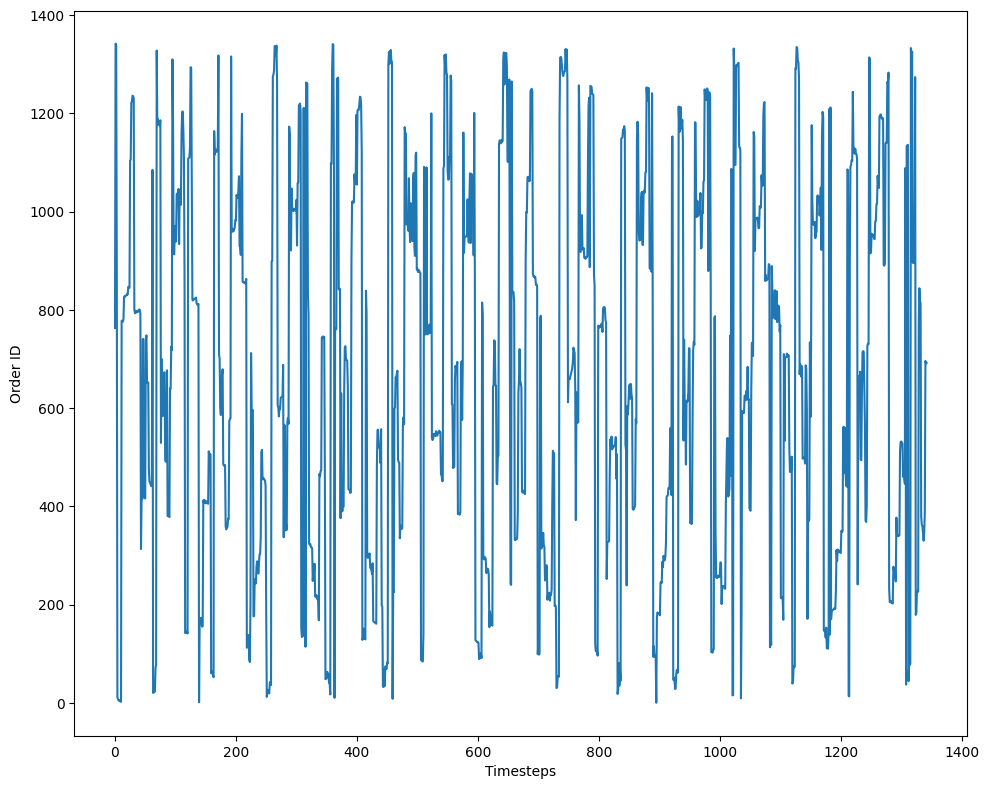

In [29]:
# Plot the contrib mechanism ordering over Autumn

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(10, 8))

windowed_contrib_order_history['order'].plot(ax=axs)

axs.set_ylabel('Order ID')
axs.set_xlabel('Timesteps')

plt.tight_layout()

plt.savefig('windowed_contrib_autumn.pdf', dpi=300, format='pdf')
plt.show()

In [30]:
# Get the order over time - Contrib

urgency_order_history = pd.DataFrame({})
urgency_order_history['order_list'] = priority_dict['urgency_testing_autumn']['order_history']
urgency_order_history.index = priority_dict['urgency_testing_autumn']['order_history'].index

urgency_order_history['order_str'] = urgency_order_history['order_list'].str.replace('[', '')
urgency_order_history['order_str'] = urgency_order_history['order_str'].str.replace(']', '')
urgency_order_history['order_str'] = urgency_order_history['order_str'].str.replace('\n', '')
#df_order_history['order_str'] = df_order_history['order_list'].apply(lambda x: ','.join(x))

# Add a column with the order encoded
unique_orders = sorted(set(urgency_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
urgency_order_history['order'] = [encoded_orders[i] for i in urgency_order_history['order_str']]
urgency_order_history.head(5)

,order_list,order_str,order
0,['ev_17' 'ev_06' 'ev_20' 'ev_08' 'ev_03' 'ev_1...,'ev_17' 'ev_06' 'ev_20' 'ev_08' 'ev_03' 'ev_16...,1321
1,['ev_13' 'ev_01' 'ev_17' 'ev_10' 'ev_20' 'ev_1...,'ev_13' 'ev_01' 'ev_17' 'ev_10' 'ev_20' 'ev_16...,1302
2,['ev_13' 'ev_01' 'ev_17' 'ev_10' 'ev_20' 'ev_1...,'ev_13' 'ev_01' 'ev_17' 'ev_10' 'ev_20' 'ev_15...,1301
3,['ev_13' 'ev_01' 'ev_17' 'ev_20' 'ev_10' 'ev_1...,'ev_13' 'ev_01' 'ev_17' 'ev_20' 'ev_10' 'ev_15...,1303
4,['ev_13' 'ev_17' 'ev_20' 'ev_01' 'ev_10' 'ev_1...,'ev_13' 'ev_17' 'ev_20' 'ev_01' 'ev_10' 'ev_18...,1305


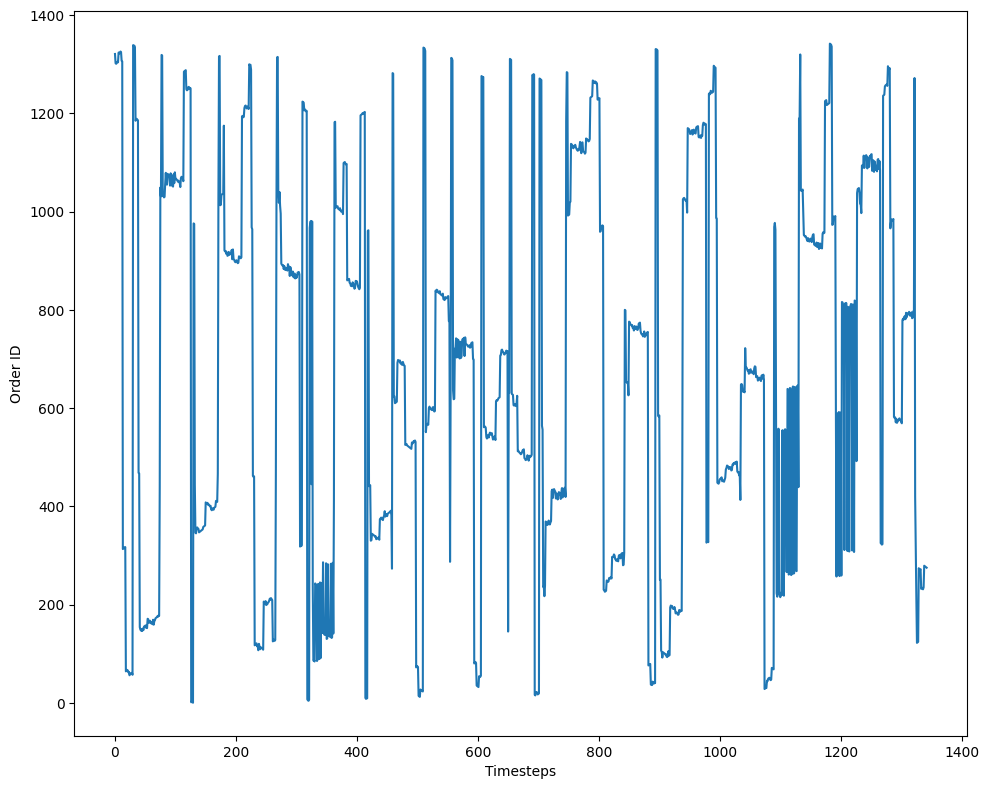

In [36]:
# Plot the contrib mechanism ordering over Autumn

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(10, 8))

urgency_order_history['order'].plot(ax=axs)

axs.set_ylabel('Order ID')
axs.set_xlabel('Timesteps')

plt.tight_layout()

plt.savefig('urgency_autumn.pdf', dpi=300, format='pdf')
plt.show()

In [32]:
# Get the order over time - Contrib

entropy_order_history = pd.DataFrame({})
entropy_order_history['order_list'] = priority_dict['entropy_testing_autumn']['order_history']
entropy_order_history.index = priority_dict['entropy_testing_autumn']['order_history'].index

entropy_order_history['order_str'] = entropy_order_history['order_list'].str.replace('[', '')
entropy_order_history['order_str'] = entropy_order_history['order_str'].str.replace(']', '')
entropy_order_history['order_str'] = entropy_order_history['order_str'].str.replace('\n', '')
#df_order_history['order_str'] = df_order_history['order_list'].apply(lambda x: ','.join(x))

# Add a column with the order encoded
unique_orders = sorted(set(entropy_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
entropy_order_history['order'] = [encoded_orders[i] for i in entropy_order_history['order_str']]
entropy_order_history.head(5)

,order_list,order_str,order
0,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
1,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
2,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
3,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
4,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0


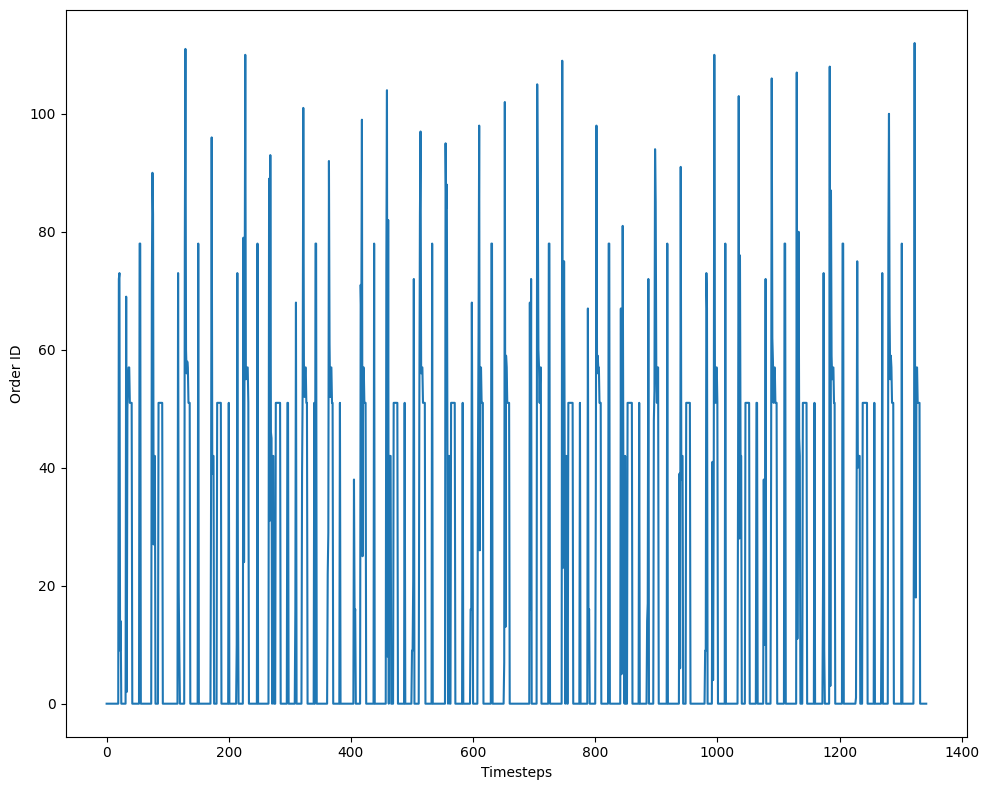

In [33]:
# Plot the contrib mechanism ordering over Autumn

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(10, 8))

entropy_order_history['order'].plot(ax=axs)

axs.set_ylabel('Order ID')
axs.set_xlabel('Timesteps')

plt.tight_layout()

plt.savefig('entropy_autumn.pdf', dpi=300, format='pdf')
plt.show()

In [35]:
entropy_order_history

,order_list,order_str,order
0,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
1,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
2,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
3,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
4,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
...,...,...,...
1338,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
1339,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
1340,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0
1341,['ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_1...,'ev_01' 'ev_12' 'ev_02' 'ev_20' 'ev_19' 'ev_18...,0


In [61]:
# Calculate the coefficient variation (CV)

df_cv = pd.DataFrame(columns=SEASONS)

for season in SEASONS:
    current_ = pd.concat([RESULTS[f'testing_{season}'].iloc[1:].astype(float).describe().transpose(), 
                          RESULTS_SS_SC[f'testing_{season}'].iloc[1:].astype(float).describe().transpose()])
    df_cv[season] = current_['std'] / current_['mean']
    
df_cv = df_cv.transpose()
df_cv = df_cv[['storCharge', 'storDischarge', 'evCharge', 'imports', 'importCost', 'exportCost', 'sc']]

# Rename the remaining columns
df_cv.columns = ['Storage Charge', 'Storage Discharge', 'EV Charge', 'Imports', 'Import Costs', 'Export Costs', 'Self-Consumption']
df_cv.index = ['Spring', 'Summer', 'Autumn', 'Winter']
df_cv = df_cv.transpose()

In [64]:
df_cv.mean()

Spring    0.052512
Summer    0.064940
Autumn    0.286422
Winter    0.057451
dtype: float64

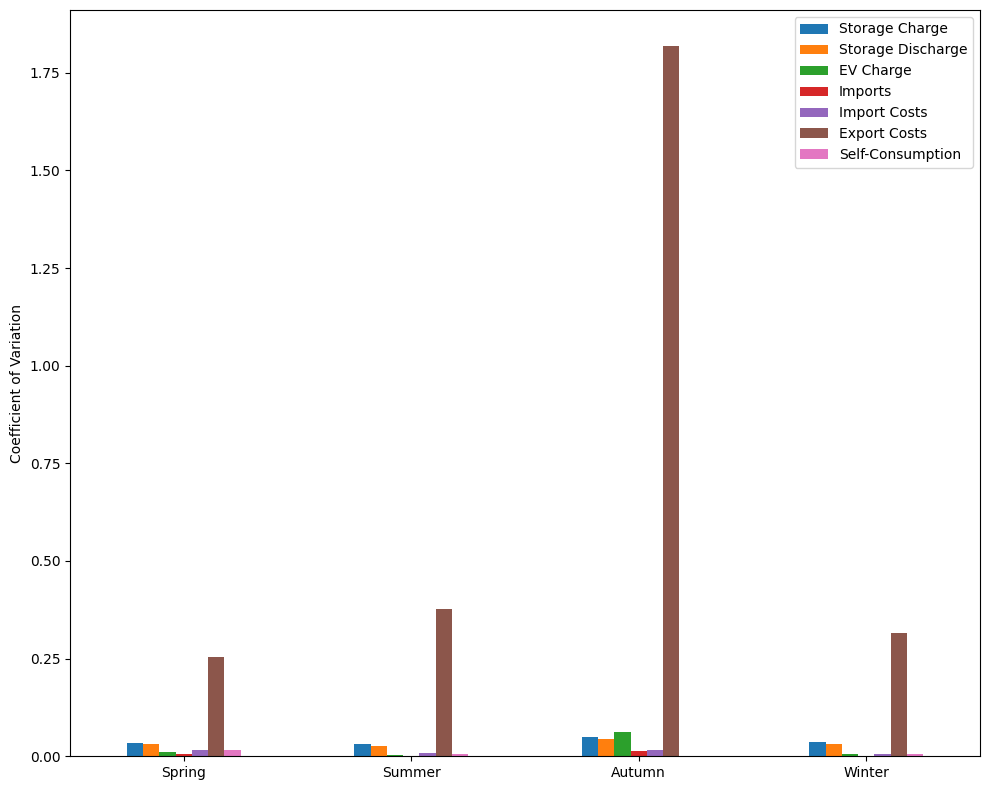

In [75]:
# Bar plot of the distribution of the CV values

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(10, 8))

df_cv.transpose().plot(kind='bar', ax=axs, rot=0)

axs.set_ylabel('Coefficient of Variation')
plt.tight_layout()

plt.savefig('cv_seasons.pdf', dpi=300, format='pdf')

plt.show()

In [84]:
df_cv.transpose().drop('Export Costs', axis=1).transpose().describe()

,Spring,Summer,Autumn,Winter
count,6.000000,6.000000,6.000000,6.000000
mean,0.019045,0.012888,0.030865,0.014422
std,0.011610,0.012510,0.024334,0.015538
min,0.004913,0.001623,0.000198,0.001231
25%,0.012102,0.004435,0.014140,0.005174
50%,0.016395,0.007284,0.029965,0.005862
75%,0.027757,0.022141,0.048688,0.025944
max,0.034356,0.030558,0.061267,0.035992


In [45]:
pd.concat([RESULTS[f'testing_{season}'].iloc[1:].astype(float).describe().transpose(), RESULTS_SS_SC[f'testing_{season}'].iloc[1:].astype(float).describe().transpose()])

,count,mean,std,min,25%,50%,75%,max
storCharge,5.0,1842.516000,66.315782,1749.210000,1824.470000,1832.970000,1878.880000,1927.050000
storDischarge,5.0,1736.948000,56.682768,1654.010000,1724.430000,1731.100000,1769.560000,1805.640000
storDischargeEff,5.0,1828.364000,59.665414,1741.060000,1815.190000,1822.210000,1862.690000,1900.670000
evCharge,5.0,3992.196000,23.454477,3965.360000,3971.320000,3994.300000,4015.000000,4015.000000
evDischarge,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
evDischargeEff,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
imports,5.0,17829.463033,21.956411,17797.385700,17818.449001,17834.711766,17844.231632,17852.537067
exports,5.0,33.178920,10.472223,16.304767,30.675800,37.153133,38.306967,43.453934
importCost,5.0,3135.835519,15.517731,3110.453619,3136.435293,3136.669791,3143.862709,3151.756182
exportCost,5.0,1.327157,0.418889,0.652191,1.227032,1.486125,1.532279,1.738157
